In [4]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

/tmp/ipykernel_5724/274628502.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_5724/274628502.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

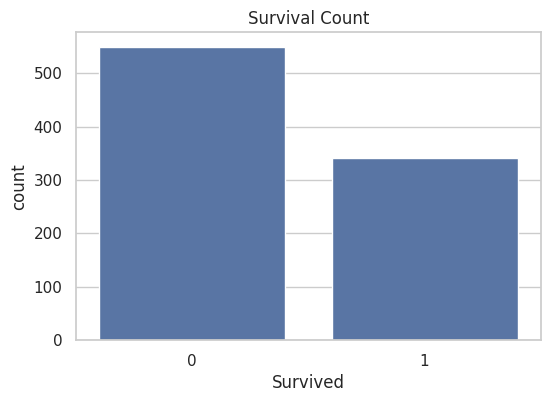

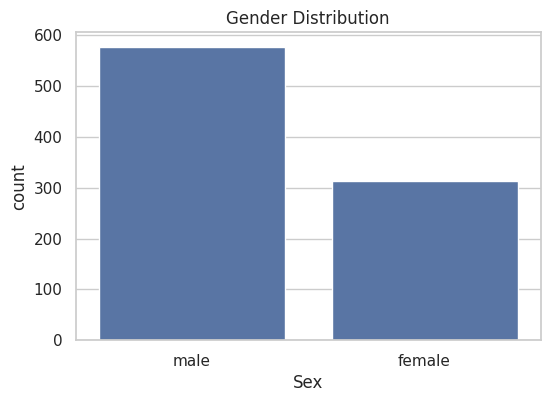

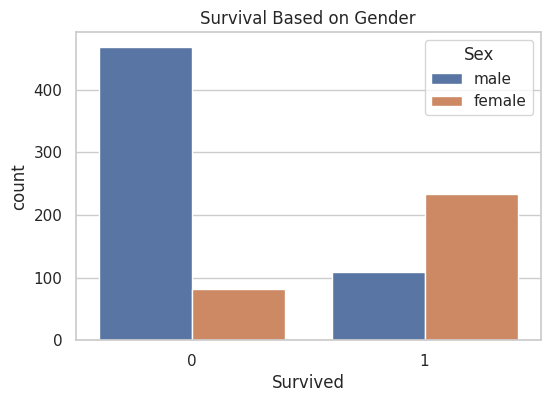

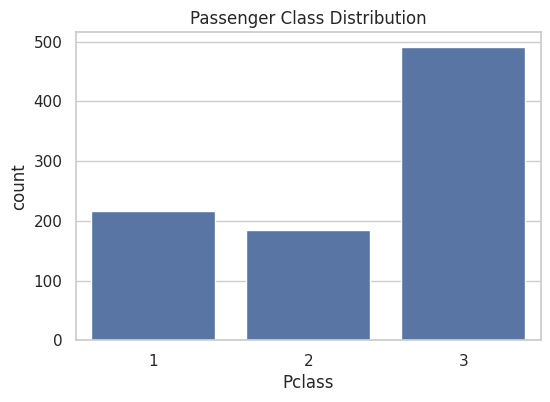

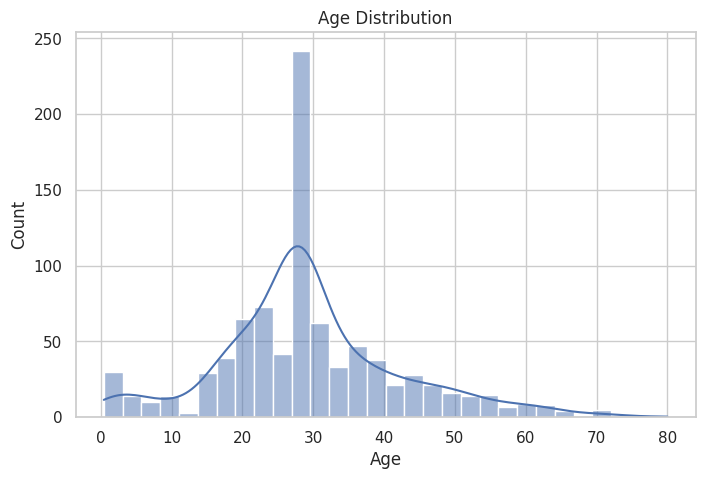

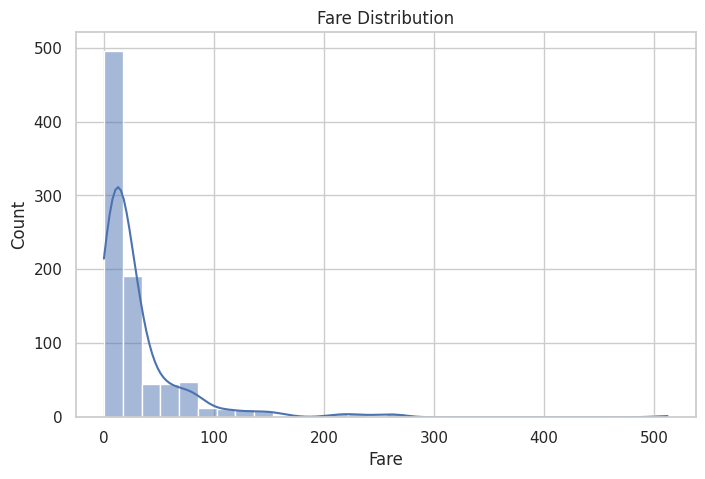

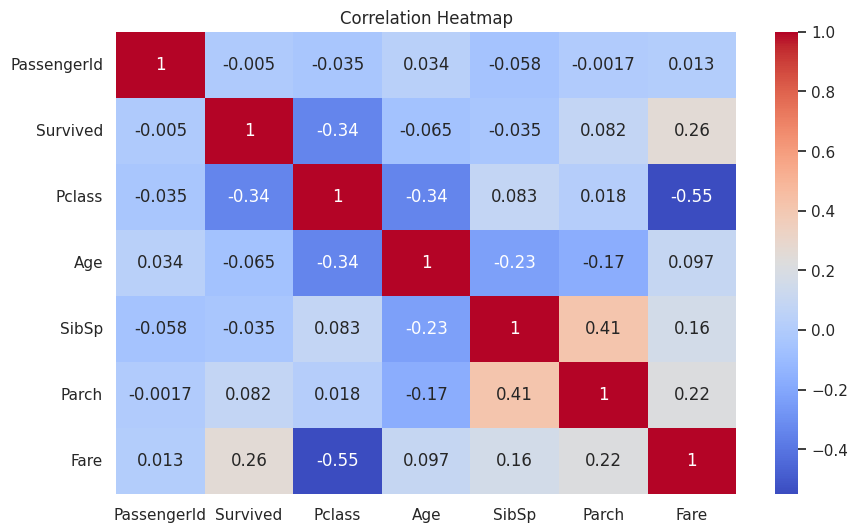


Observations:
1. Females had higher survival rates.
2. First-class passengers survived more.
3. Most passengers were between 20-40 years old.
4. Fare distribution is positively skewed.


In [5]:
# ================================
# TASK-02 : Data Cleaning and EDA
# Titanic Dataset
# ================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('train.csv')

# Display first 5 rows
print("First 5 Rows")
print(df.head())

# Dataset Information
print("\nDataset Info")
print(df.info())

# Check Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# --------------------------------
# DATA CLEANING
# --------------------------------

# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column because many values are missing
df.drop('Cabin', axis=1, inplace=True)

# Verify missing values again
print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# --------------------------------
# EXPLORATORY DATA ANALYSIS (EDA)
# --------------------------------

# Set Style
sns.set(style='whitegrid')

# 1. Survival Count
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

# 2. Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()

# 3. Survival based on Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival Based on Gender')
plt.show()

# 4. Passenger Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

# 5. Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

# 6. Fare Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.show()

# 7. Correlation Heatmap
plt.figure(figsize=(10,6))

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# --------------------------------
# OBSERVATIONS
# --------------------------------

print("\nObservations:")
print("1. Females had higher survival rates.")
print("2. First-class passengers survived more.")
print("3. Most passengers were between 20-40 years old.")
print("4. Fare distribution is positively skewed.")